# 使用 ABSESpy `ExperimentManager` 分析 Hydra Multirun 结果

本 notebook 演示如何把一次 Hydra 多参数扫描的输出（`out/south_china_evolution/<日期>/<时间>/`）回填进 `abses.core.experiment.ExperimentManager`，从而获得一张统一的 `(job_id, run_id)` × `参数 + 指标` 长表。

示例选用最近一次 `Farmer/Hunter/RiceFarmer.max_travel_distance ∈ {5,10,20}` 的 27 组×5 重复扫描：`out/south_china_evolution/2026-03-23/21-11-24/`。

**核心思路**：

1. 解析 `multirun.yaml` 的 `hydra.overrides.override_dirname` 提取本次扫描了哪些参数与取值。
2. 遍历 27 个 `<job_id>_<override_dirname>` 子目录，读出每个 repeat 的 `*_tracking.csv` 终态指标与 `repeat_*_conversion.csv` 转化矩阵。
3. 调用 `ExperimentManager.update_result((job_id, run_id), overrides=..., datasets=...)` 注册每条结果。
4. 用 `manager.get_datasets()` 拿到长表，做透视、聚合、可视化。

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from omegaconf import OmegaConf

from abses.core.experiment import ExperimentManager
from src.core import Model

MULTIRUN_DIR = Path("../out/south_china_evolution/2026-03-23/21-11-24").resolve()
assert MULTIRUN_DIR.exists(), MULTIRUN_DIR

## 1. 读取 multirun.yaml 还原扫描计划

In [2]:
cfg = OmegaConf.load(MULTIRUN_DIR / "multirun.yaml")
# Hydra stores the sweep in `hydra.overrides.task` as a list of
# `key=val1,val2,...` strings.
task_overrides = list(cfg.hydra.overrides.task)
swept: dict[str, list[str]] = {}
for token in task_overrides:
    key, vals = token.split("=", 1)
    swept[key] = [v.strip() for v in vals.split(",")]
swept

{'Farmer.max_travel_distance': ['5', '10', '20'],
 'RiceFarmer.max_travel_distance': ['5', '10', '20'],
 'Hunter.max_travel_distance': ['5', '10', '20']}

## 2. 解析每个 job 子目录的 overrides

目录命名规则为 `<job_id>_<key>=<val>,<key>=<val>,...`，与 `output_data_guide.md §2.1` 一致。

In [3]:
JOB_DIR_RE = re.compile(r"^(?P<job_id>\d+)_(?P<rest>.+)$")


def parse_job_dir(name: str) -> tuple[int, dict[str, float]]:
    """Return (job_id, overrides) from a Hydra job sub-directory name."""
    m = JOB_DIR_RE.match(name)
    if not m:
        raise ValueError(name)
    job_id = int(m.group("job_id"))
    overrides: dict[str, float] = {}
    for token in m.group("rest").split(","):
        if "=" not in token:
            continue
        k, v = token.split("=", 1)
        try:
            overrides[k] = float(v) if "." in v else int(v)
        except ValueError:
            overrides[k] = v
    return job_id, overrides


job_dirs = sorted(
    [p for p in MULTIRUN_DIR.iterdir() if p.is_dir() and JOB_DIR_RE.match(p.name)],
    key=lambda p: int(JOB_DIR_RE.match(p.name).group("job_id")),
)
len(job_dirs), parse_job_dir(job_dirs[0].name)

(24,
 (0,
  {'Farmer.max_travel_distance': 5,
   'Hunter.max_travel_distance': 5,
   'RiceFarmer.max_travel_distance': 5}))

## 3. 把每条 repeat 的指标喂给 `ExperimentManager`

`ExperimentManager` 的接口 (`abses.core.experiment.ExperimentManager`) 只要求每条结果是行式 mapping，因此我们提取**终态**（最后一步）作为该 repeat 的指标，再把转化矩阵的若干汇总值一并塞进同一行。

注意 `ExperimentManager` 是单例（`__new__` 锁定 `model_cls`），跨 cell 重复实例化都会拿到同一个对象。

In [4]:
TRACK_RE = re.compile(r"^(?P<run_id>\d+)_tracking\.csv$")

METRIC_COLS = [
    "len_farmers",
    "len_hunters",
    "len_rice",
    "num_farmers",
    "num_hunters",
    "num_rice",
    "len_farmers_n",
    "len_hunters_n",
    "len_rice_n",
    "num_farmers_n",
    "num_hunters_n",
    "num_rice_n",
]


def summarize_repeat(track_path: Path, conv_path: Path | None) -> dict[str, float]:
    """Build a row-like metric dict for one repeat."""
    track = pd.read_csv(track_path)
    final = track.iloc[-1]
    row: dict[str, float] = {
        f"final_{c}": float(final[c]) for c in METRIC_COLS if c in track
    }
    row["final_step"] = int(final["step"])
    # Mean population over the second half (steady-state proxy)
    half = track[track["step"] >= track["step"].max() // 2]
    for c in ("num_farmers", "num_hunters", "num_rice"):
        if c in half:
            row[f"mean2nd_{c}"] = float(half[c].mean())
    if conv_path is not None and conv_path.exists():
        conv = pd.read_csv(conv_path, index_col=0)
        # diagonal retention rates
        for kind, end_row, init_col in (
            ("farmer", "farmers_end", "farmer_init"),
            ("hunter", "hunters_end", "hunter_init"),
            ("rice", "rice_end", "rice_init"),
        ):
            tot = (
                conv.loc["total_end", init_col] if init_col in conv.columns else np.nan
            )
            kept = (
                conv.loc[end_row, init_col]
                if (end_row in conv.index and init_col in conv.columns)
                else np.nan
            )
            row[f"retain_{kind}"] = float(kept / tot) if tot else np.nan
    return row


manager = ExperimentManager(Model)
manager.clean()

missing: list[tuple[int, int]] = []
for job_dir in job_dirs:
    job_id, overrides = parse_job_dir(job_dir.name)
    for track_path in sorted(job_dir.glob("*_tracking.csv")):
        m = TRACK_RE.match(track_path.name)
        if not m:
            continue
        run_id = int(m.group("run_id"))
        conv_path = job_dir / f"repeat_{run_id}_conversion.csv"
        try:
            row = summarize_repeat(track_path, conv_path)
        except Exception as exc:  # noqa: BLE001
            missing.append((job_id, run_id))
            print(f"skip ({job_id},{run_id}): {exc}")
            continue
        manager.update_result(
            key=(job_id, run_id),
            overrides=overrides,
            datasets=row,
        )

print(f"loaded {len(manager._datasets)} repeats; missing={len(missing)}")

loaded 117 repeats; missing=0


## 4. `get_datasets()` 拿到长表

返回的 DataFrame 列结构：`job_id, run_id, <扫描参数...>, seed, <指标...>`。

In [5]:
df = manager.get_datasets(seed=False)  # multirun 不会回填种子
df.head()

/var/folders/s9/w7bh_d6x1h915wcvpbp117tm0000gn/T/ipykernel_39749/1629995096.py:1: DeprecationWarning: Column 'repeat_id' is deprecated and will be removed in a future version. Please use 'run_id' instead.
  df = manager.get_datasets(seed=False)  # multirun 不会回填种子


,job_id,repeat_id,Farmer.max_travel_distance,Hunter.max_travel_distance,RiceFarmer.max_travel_distance,final_len_farmers,final_len_hunters,final_len_rice,final_num_farmers,final_num_hunters,...,final_num_hunters_n,final_num_rice_n,final_step,mean2nd_num_farmers,mean2nd_num_hunters,mean2nd_num_rice,retain_farmer,retain_hunter,retain_rice,run_id
0,0,1,5,5,5,0.045702,0.941199,0.013099,0.053142,0.792529,...,239225.0,46584.0,500,0.051219,0.839434,0.109347,0.063845,0.984896,0.194940,1
1,0,2,5,5,5,0.042979,0.946860,0.010161,0.049089,0.825651,...,239225.0,36293.0,500,0.047461,0.868909,0.083629,0.063691,0.986108,0.202105,2
2,0,3,5,5,5,0.046088,0.943824,0.010088,0.049105,0.827728,...,239225.0,35597.0,500,0.051958,0.864515,0.083526,0.069237,0.985956,0.172232,3
3,0,4,5,5,5,0.051743,0.936605,0.011652,0.059547,0.800383,...,239225.0,41865.0,500,0.051976,0.847246,0.100777,0.073166,0.984671,0.176651,4
4,0,5,5,5,5,0.047879,0.942585,0.009536,0.057303,0.811760,...,239225.0,38587.0,500,0.050341,0.860111,0.089548,0.070510,0.987420,0.169611,5


In [6]:
param_cols = list(swept.keys())
agg = (
    df.groupby(param_cols)
    .agg(
        n=("run_id", "count"),
        farmer_share_mean=("final_num_farmers", "mean"),
        farmer_share_std=("final_num_farmers", "std"),
        rice_share_mean=("final_num_rice", "mean"),
        hunter_share_mean=("final_num_hunters", "mean"),
    )
    .reset_index()
)
agg.head(10)

,Farmer.max_travel_distance,RiceFarmer.max_travel_distance,Hunter.max_travel_distance,n,farmer_share_mean,farmer_share_std,rice_share_mean,hunter_share_mean
0,5,5,5,5,0.053637,0.004739,0.134752,0.811611
1,5,5,10,5,0.050796,0.002310,0.123890,0.825314
2,5,5,20,5,0.051850,0.002423,0.118092,0.830058
3,5,10,5,5,0.052894,0.001116,0.106053,0.841052
4,5,10,10,5,0.055796,0.003872,0.105981,0.838223
5,5,10,20,5,0.055630,0.003552,0.107483,0.836887
6,5,20,5,5,0.054195,0.003793,0.095372,0.850434
7,5,20,10,5,0.057228,0.004876,0.098027,0.844745
8,5,20,20,5,0.056848,0.002423,0.100936,0.842217
9,10,5,5,5,0.051230,0.002338,0.133629,0.815141


## 5. 可视化：参数对终态人口结构的影响

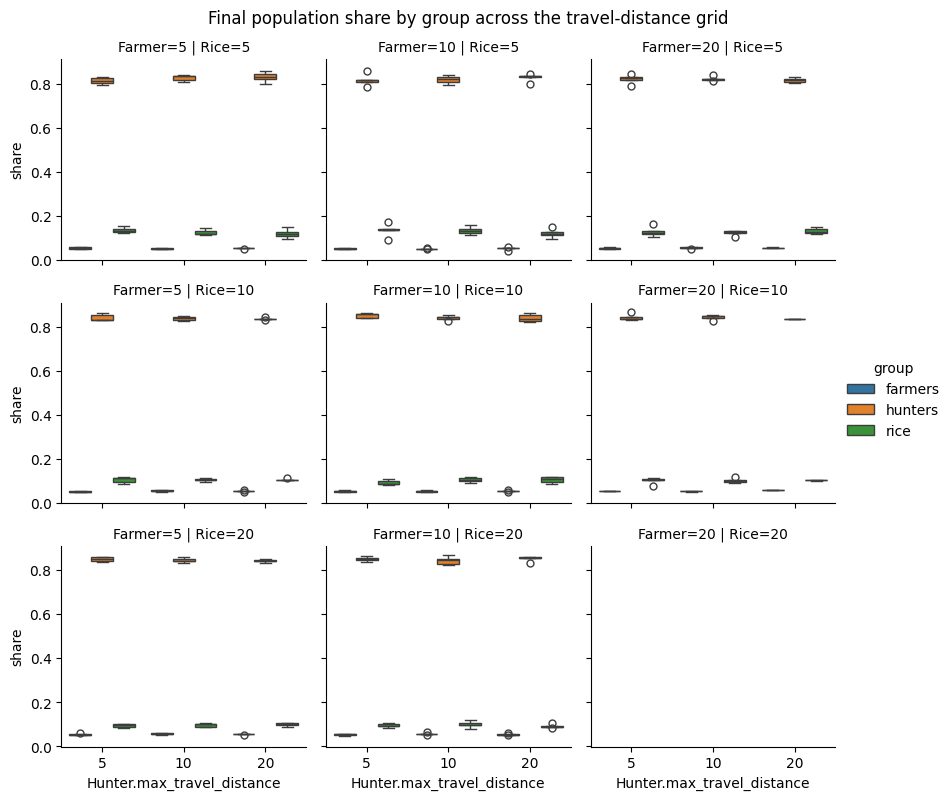

In [7]:
long = df.melt(
    id_vars=["job_id", "run_id", *param_cols],
    value_vars=["final_num_farmers", "final_num_hunters", "final_num_rice"],
    var_name="group",
    value_name="share",
)
long["group"] = long["group"].str.replace("final_num_", "", regex=False)

g = sns.catplot(
    data=long,
    x="Hunter.max_travel_distance",
    y="share",
    hue="group",
    col="Farmer.max_travel_distance",
    row="RiceFarmer.max_travel_distance",
    kind="box",
    height=2.6,
    aspect=1.1,
    sharey=True,
)
g.set_titles("Farmer={col_name} | Rice={row_name}")
g.fig.suptitle(
    "Final population share by group across the travel-distance grid", y=1.02
)
plt.show()

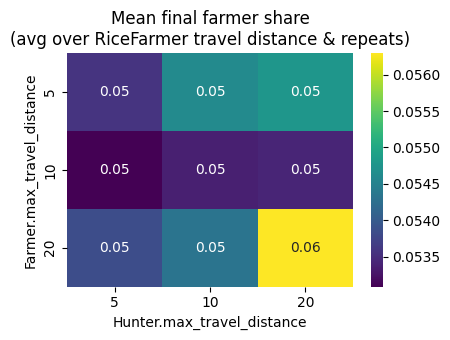

In [8]:
# Heatmap: average farmer share, averaged over RiceFarmer travel distance
pivot = (
    df.groupby(["Farmer.max_travel_distance", "Hunter.max_travel_distance"])[
        "final_num_farmers"
    ]
    .mean()
    .unstack()
)
fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean final farmer share\n(avg over RiceFarmer travel distance & repeats)")
plt.tight_layout()
plt.show()

## 6. 转化矩阵保留率

由 `summarize_repeat` 注入的 `retain_*` 字段反映了三类主体在该参数组合下保持原类型的比例。

In [9]:
retain_cols = [c for c in df.columns if c.startswith("retain_")]
df[[*param_cols, *retain_cols]].groupby(param_cols).mean().round(3).head(10)

retain_farmer  \
Farmer.max_travel_distance RiceFarmer.max_travel_distance Hunter.max_travel_distance                  
5                          5                              5                                   0.068   
                                                          10                                  0.064   
                                                          20                                  0.065   
                           10                             5                                   0.067   
                                                          10                                  0.070   
                                                          20                                  0.070   
                           20                             5                                   0.068   
                                                          10                                  0.067   
                                                          20                                  0.069   
10                         5                              5                                   0.068   

                                                                                      retain_hunter  \
Farmer.max_travel_distance RiceFarmer.max_travel_distance Hunter.max_travel_distance                  
5                          5                              5                                   0.986   
                                                          10                                  0.985   
                                                          20                                  0.985   
                           10                             5                                   0.986   
                                                          10                                  0.987   
                                                          20                                  0.986   
                           20                             5                                   0.986   
                                                          10                                  0.984   
                                                          20                                  0.986   
10                         5                              5                                   0.985   

                                                                                      retain_rice  
Farmer.max_travel_distance RiceFarmer.max_travel_distance Hunter.max_travel_distance               
5                          5                              5                                 0.183  
                                                          10                                0.199  
                                                          20                                0.192  
                           10                             5                                 0.165  
                                                          10                                0.158  
                                                          20                                0.165  
                           20                             5                                 0.153  
                                                          10                                0.157  
                                                          20                                0.152  
10                         5                              5                                 0.192

## 7. 自定义 hook（可选）

`ExperimentManager.add_a_hook` 允许把额外的回调（例如自定义指标计算、写盘）挂到 manager 上，以便在批量实验流水线中统一触发。这里仅展示注册方式。

In [10]:
def report_summary(manager: ExperimentManager) -> pd.DataFrame:
    """Example hook: emit a per-job summary table."""
    return manager.get_datasets(seed=False).groupby("job_id").mean(numeric_only=True)


if "report_summary" not in manager.hooks:
    manager.add_a_hook(report_summary)
manager.hooks["report_summary"](manager).head()

/var/folders/s9/w7bh_d6x1h915wcvpbp117tm0000gn/T/ipykernel_39749/331908036.py:3: DeprecationWarning: Column 'repeat_id' is deprecated and will be removed in a future version. Please use 'run_id' instead.
  return manager.get_datasets(seed=False).groupby("job_id").mean(numeric_only=True)


,repeat_id,Farmer.max_travel_distance,Hunter.max_travel_distance,RiceFarmer.max_travel_distance,final_len_farmers,final_len_hunters,final_len_rice,final_num_farmers,final_num_hunters,final_num_rice,...,final_num_hunters_n,final_num_rice_n,final_step,mean2nd_num_farmers,mean2nd_num_hunters,mean2nd_num_rice,retain_farmer,retain_hunter,retain_rice,run_id
job_id,,,,,,,,,,,,,,,,,,,,,
0,3.0,5.0,5.0,5.0,0.046878,0.942215,0.010907,0.053637,0.811611,0.134752,...,239225.0,39785.2,500.0,0.050591,0.856043,0.093366,0.068090,0.985810,0.183108,3.0
1,3.0,5.0,10.0,5.0,0.044507,0.945129,0.010364,0.050796,0.825314,0.123890,...,239225.0,35970.6,500.0,0.049831,0.867380,0.082789,0.063812,0.984946,0.199022,3.0
2,3.0,5.0,20.0,5.0,0.045473,0.943824,0.010703,0.051850,0.830058,0.118092,...,239225.0,34176.2,500.0,0.050605,0.865850,0.083545,0.064707,0.984555,0.191522,3.0
3,3.0,5.0,5.0,10.0,0.046424,0.942826,0.010750,0.052894,0.841052,0.106053,...,239225.0,30229.6,500.0,0.052481,0.869294,0.078224,0.066866,0.985896,0.164569,3.0
4,3.0,5.0,10.0,10.0,0.047667,0.941361,0.010972,0.055796,0.838223,0.105981,...,239225.0,30269.0,500.0,0.053562,0.867358,0.079080,0.070114,0.986628,0.158222,3.0


## 8. 按参数组合比较人口增长轨迹

前面的分析只用了 `tracking.csv` 的**末态**作为每条 repeat 的指标，丢掉了增长过程。
这一节把全部时间序列加载进一张长表，按 `(params, step)` 聚合 5 次 repeat 的均值与置信区间，
在参数网格上直接对比"农民增长快/慢"的两类轨迹。

In [11]:
def load_trajectories(job_dirs, track_re, metric_cols):
    """Concatenate every repeat's tracking.csv with its parameter overrides."""
    frames = []
    for jd in job_dirs:
        job_id, overrides = parse_job_dir(jd.name)
        for tp in sorted(jd.glob("*_tracking.csv")):
            m = track_re.match(tp.name)
            if not m:
                continue
            run_id = int(m.group("run_id"))
            t = pd.read_csv(tp, usecols=["step", *metric_cols])
            t["job_id"] = job_id
            t["run_id"] = run_id
            for k, v in overrides.items():
                t[k] = v
            frames.append(t)
    return pd.concat(frames, ignore_index=True)


traj = load_trajectories(job_dirs, TRACK_RE, METRIC_COLS)
print(traj.shape)
traj.head()

(58617, 18)


,step,len_farmers,len_hunters,len_rice,num_farmers,num_hunters,num_rice,len_farmers_n,len_hunters_n,len_rice_n,num_farmers_n,num_hunters_n,num_rice_n,job_id,run_id,Farmer.max_travel_distance,Hunter.max_travel_distance,RiceFarmer.max_travel_distance
0,0,0.001432,0.998281,0.000286,0.000619,0.998230,0.001151,5.0,3485,1.0,114.0,183868.0,212.0,0,1,5,5,5
1,1,0.003998,0.995717,0.000286,0.002956,0.995891,0.001153,14.0,3487,1.0,546.0,183971.0,213.0,0,1,5,5,5
2,2,0.005130,0.994585,0.000285,0.004427,0.994417,0.001157,18.0,3490,1.0,819.0,183988.0,214.0,0,1,5,5,5
3,3,0.005973,0.993743,0.000284,0.004978,0.993856,0.001166,21.0,3494,1.0,922.0,184080.0,216.0,0,1,5,5,5
4,4,0.006536,0.993180,0.000284,0.005793,0.993036,0.001170,23.0,3495,1.0,1074.0,184104.0,217.0,0,1,5,5,5


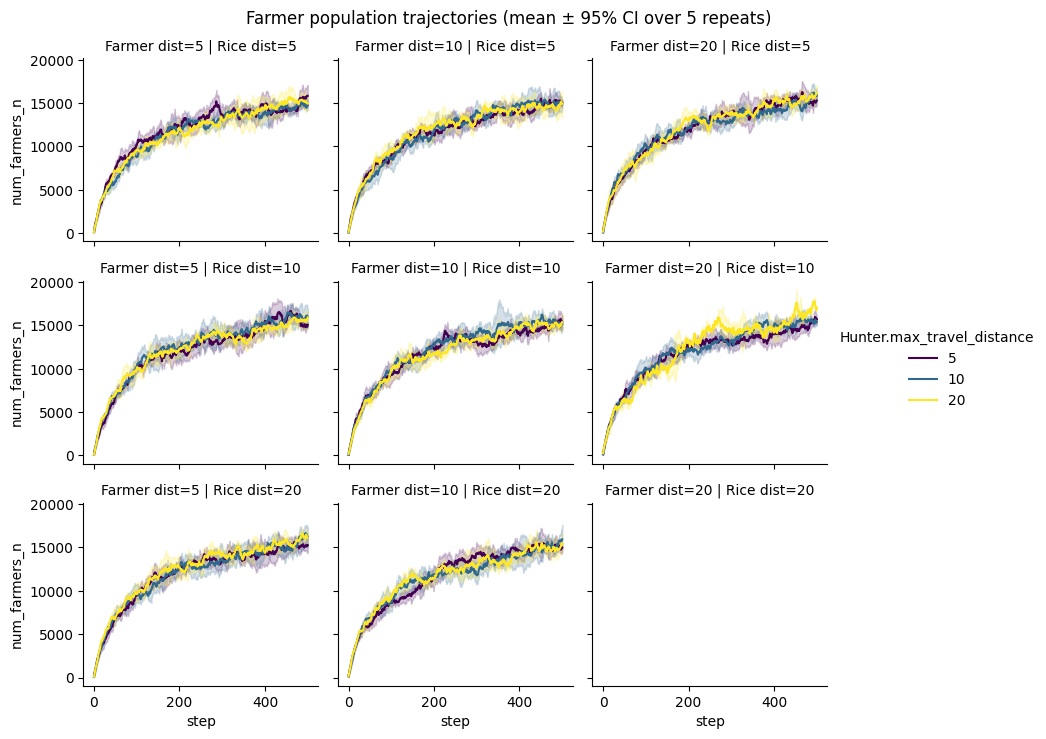

In [ ]:
# Mean farmer population over time, grouped by every swept parameter combination.
# seaborn.lineplot averages over `run_id` automatically and draws a 95% CI band.
g = sns.relplot(
    data=traj,
    x="step",
    y="num_farmers_n",
    hue="Hunter.max_travel_distance",
    col="Farmer.max_travel_distance",
    row="RiceFarmer.max_travel_distance",
    kind="line",
    estimator="mean",
    errorbar=("ci", 95),
    height=2.4,
    aspect=1.2,
    palette="viridis",
    facet_kws={"sharey": True},
)
g.set_titles("Farmer dist={col_name} | Rice dist={row_name}")
g.fig.suptitle("Farmer population trajectories (mean ± 95% CI over 5 repeats)", y=1.02)
plt.show()

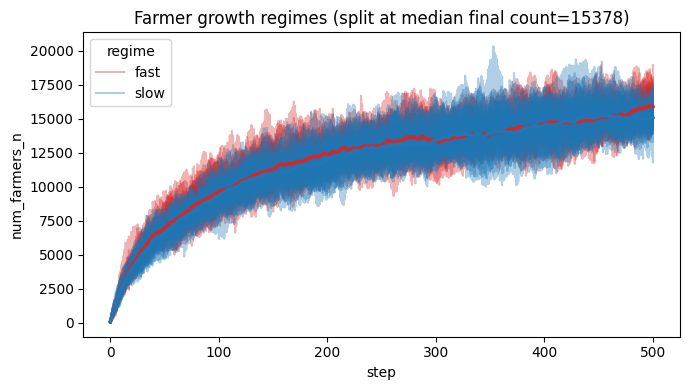

Hunter.max_travel_distance                                   5     10    20
Farmer.max_travel_distance RiceFarmer.max_travel_distance                  
5                          5                               fast  slow  slow
                           10                              slow  fast  fast
                           20                              slow  fast  fast
10                         5                               slow  slow  slow
                           10                              fast  slow  slow
                           20                              slow  fast  slow
20                         5                               slow  fast  fast
                           10                              fast  fast  fast

In [13]:
# Classify each job_id as fast- vs slow-farmer-growth by its mean-over-repeats
# final farmer count, then overlay all trajectories colored by class so the
# two growth regimes are visually obvious.
final_farmer = (
    traj.sort_values("step")
    .groupby(["job_id", "run_id"])["num_farmers_n"]
    .last()
    .groupby("job_id")
    .mean()
)
threshold = final_farmer.median()
fast_jobs = set(final_farmer[final_farmer >= threshold].index)
traj["regime"] = np.where(traj["job_id"].isin(fast_jobs), "fast", "slow")

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(
    data=traj,
    x="step",
    y="num_farmers_n",
    units="job_id",
    estimator=None,
    hue="regime",
    palette={"fast": "#d62728", "slow": "#1f77b4"},
    alpha=0.35,
    ax=ax,
)
sns.lineplot(
    data=traj,
    x="step",
    y="num_farmers_n",
    hue="regime",
    palette={"fast": "#d62728", "slow": "#1f77b4"},
    estimator="mean",
    errorbar=None,
    linewidth=2.5,
    legend=False,
    ax=ax,
)
ax.set_title(f"Farmer growth regimes (split at median final count={threshold:.0f})")
ax.set_ylabel("num_farmers_n")
plt.tight_layout()
plt.show()

# Which parameter combinations fall into the fast-growth regime?
df.assign(regime=np.where(df["job_id"].isin(fast_jobs), "fast", "slow")).groupby(
    param_cols
)["regime"].agg(lambda s: s.mode().iat[0]).unstack("Hunter.max_travel_distance")

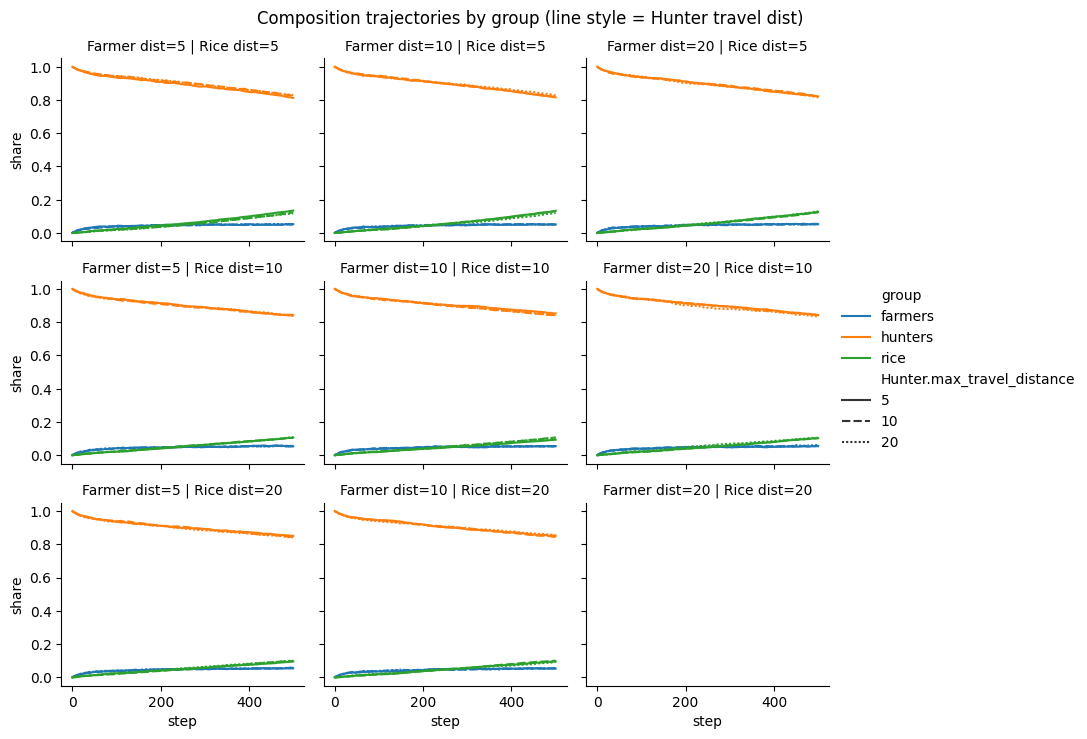

In [14]:
# Composition view: how the three shares evolve side-by-side for every grid cell.
share_long = traj.melt(
    id_vars=["step", "job_id", "run_id", *param_cols],
    value_vars=["num_farmers", "num_hunters", "num_rice"],
    var_name="group",
    value_name="share",
)
share_long["group"] = share_long["group"].str.replace("num_", "", regex=False)

g = sns.relplot(
    data=share_long,
    x="step",
    y="share",
    hue="group",
    col="Farmer.max_travel_distance",
    row="RiceFarmer.max_travel_distance",
    style="Hunter.max_travel_distance",
    kind="line",
    estimator="mean",
    errorbar=None,
    height=2.4,
    aspect=1.2,
    facet_kws={"sharey": True},
)
g.set_titles("Farmer dist={col_name} | Rice dist={row_name}")
g.fig.suptitle(
    "Composition trajectories by group (line style = Hunter travel dist)", y=1.02
)
plt.show()